In [1]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import greedy_policy_from_V, plot_and_evaluate, plot_convergence
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
num_rows = 10
num_cols = 15
start_state = (3, 3)
goal_state = (9, 12)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 250 # used for episodic evaluation


In [5]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
V  = np.zeros(num_states) # initialization for V(s)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration
for i in range(max_number_iterations):
    delta = 0
    V_new = np.zeros(num_states)
    for state in range(num_states):
        if env.is_terminal_state(state):
            continue
        v_a = []
        for a in ACTIONS:
            val = 0
            for prob, next_state in env.get_transition_distribution(state, a):
                val += prob * (env.reward(state, a, next_state) + gamma * V[next_state])
            v_a.append(val)
        V_new[state] = max(v_a)
        delta = max(delta, abs(V_new[state] - V[state]))
    
    V = V_new
    if delta < threshold:
        print(f"Value Iteration converged after {i+1} iterations.")
        break

Value Iteration converged after 52 iterations.


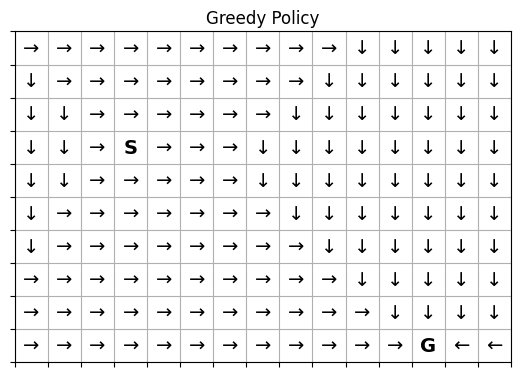

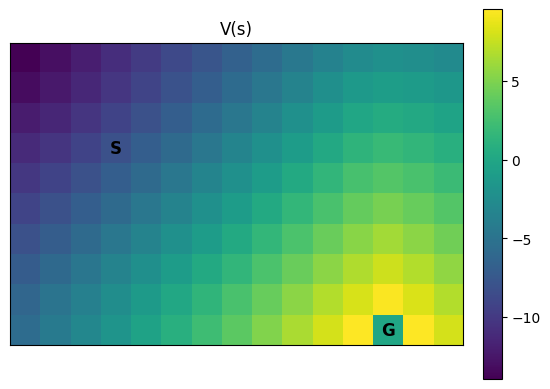

{'avg_return': -7.8, 'std_return': 2.8142, 'success_rate': 1.0, 'avg_steps': 18.8}


In [6]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

pi = greedy_policy_from_V(V, env, gamma)

metrics = plot_and_evaluate(
    env,
    policy=pi,
    V=V,
    policy_plot_name=policy_plot_name,
    value_plot_name=value_plot_name,
    policy_title="Greedy Policy",
    value_title="V(s)",
    n_val_episodes=n_val_episodes,
    seed=random_seed,
    gif_name=gif_name,
    fps=6,
 )
print(metrics)

# Q-learning

In [7]:
# Q-Learning hyperparameters
n_episodes_ql = 20_000
alpha = 0.2
epsilon = 0.80
epsilon_min = 0.01
epsilon_decay = 0.9999


In [8]:
from helpers.rl import (
    q_learning,
    sarsa,
 )

In [9]:
env.reset()

Q, rewards_ql = q_learning(
    env,
    n_episodes=n_episodes_ql,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    seed=random_seed,
)

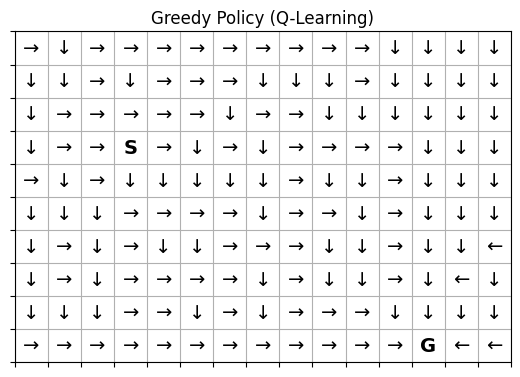

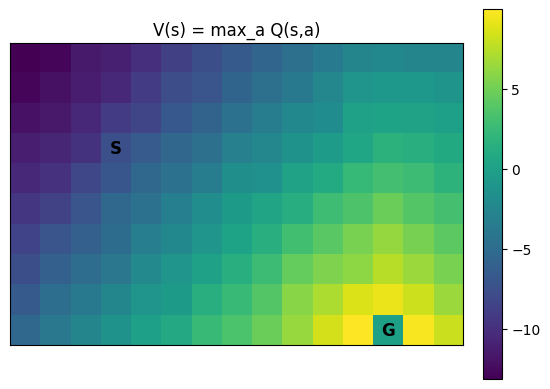

{'avg_return': -7.96, 'std_return': 3.0657, 'success_rate': 1.0, 'avg_steps': 18.96}


In [10]:
policy_plot_name_ql = "policy_QL.png"
value_plot_name_ql  = "value_QL.png"
gif_name_ql         = "episode_QL.gif"
n_val_episodes_ql   = 50

metrics_ql = plot_and_evaluate(
    env,
    Q=Q,
    policy_plot_name=policy_plot_name_ql,
    value_plot_name=value_plot_name_ql,
    policy_title="Greedy Policy (Q-Learning)",
    value_title="V(s) = max_a Q(s,a)",
    n_val_episodes=n_val_episodes_ql,
    seed=random_seed,
    gif_name=gif_name_ql,
    fps=6,
 )
print(metrics_ql)


# Sarsa

In [11]:
# sarsa parameters
n_episodes_sarsa = 20_000
alpha_sarsa = 0.2
epsilon_sarsa = 0.80
epsilon_min_sarsa = 0.01
epsilon_decay_sarsa = 0.9999


In [12]:
env.reset()

Q, rewards_sarsa = sarsa(
    env,
    n_episodes=n_episodes_sarsa,
    alpha=alpha_sarsa,
    gamma=gamma,
    epsilon=epsilon_sarsa,
    epsilon_min=epsilon_min_sarsa,
    epsilon_decay=epsilon_decay_sarsa,
    seed=random_seed,
)

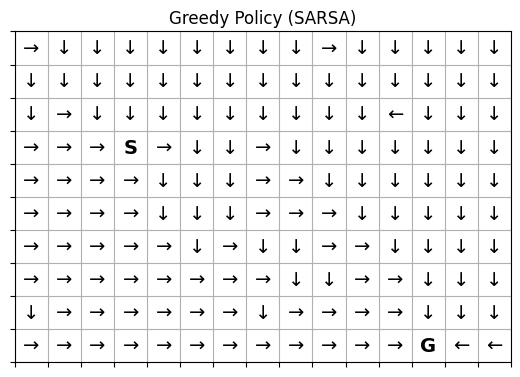

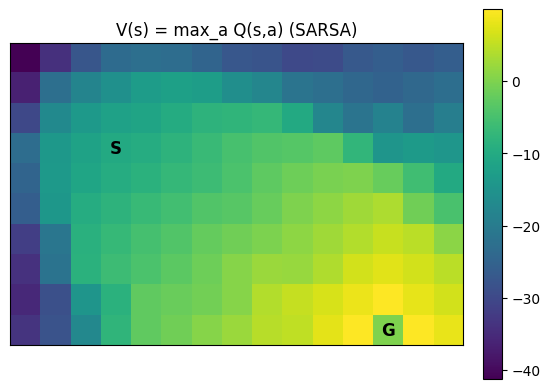

{'avg_return': -8.04, 'std_return': 2.9729, 'success_rate': 1.0, 'avg_steps': 19.04}


In [13]:
policy_plot_name_sarsa = "policy_SARSA.png"
value_plot_name_sarsa  = "value_SARSA.png"
gif_name_sarsa         = "episode_SARSA.gif"

metrics_sarsa = plot_and_evaluate(
    env,
    Q=Q,
    policy_plot_name=policy_plot_name_sarsa,
    value_plot_name=value_plot_name_sarsa,
    policy_title="Greedy Policy (SARSA)",
    value_title="V(s) = max_a Q(s,a) (SARSA)",
    n_val_episodes=n_val_episodes_ql,
    seed=random_seed,
    gif_name=gif_name_sarsa,
    fps=6,
 )
print(metrics_sarsa)


# Convergence comparison

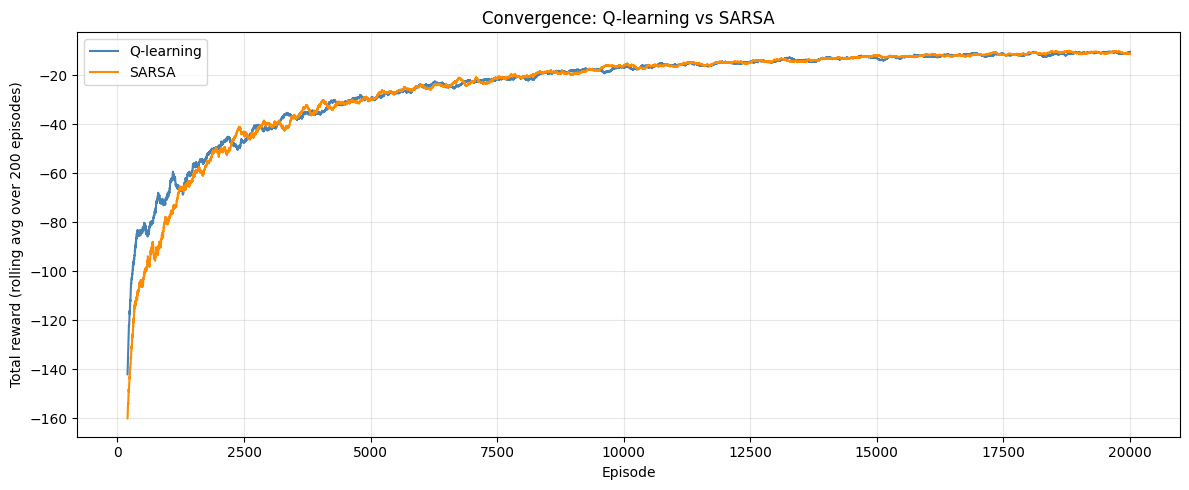

In [14]:
plot_convergence(
    rewards_ql,
    rewards_sarsa,
    window=200,
    filename="convergence.png",
 )
